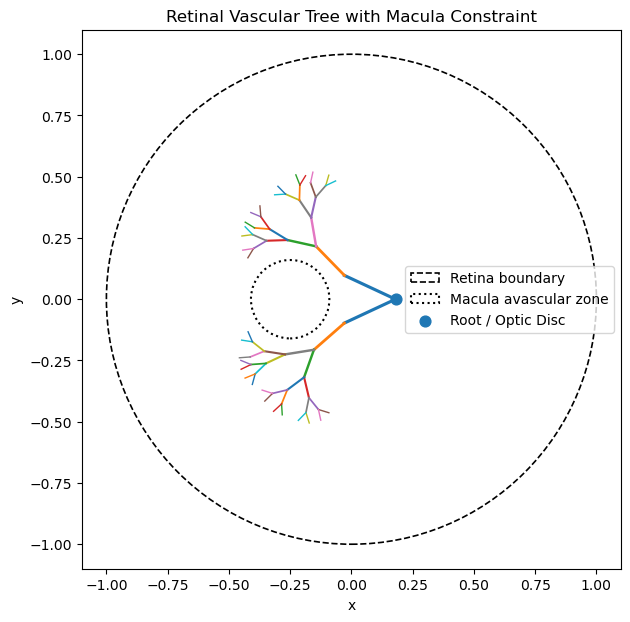

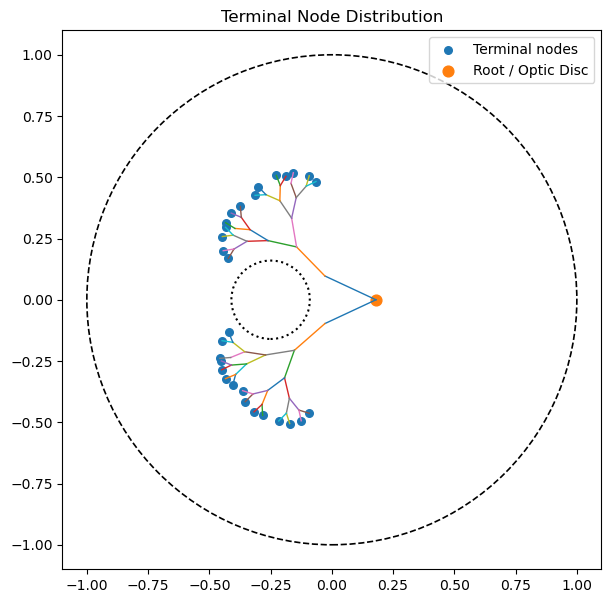

Number of edges: 61
Number of nodes: 62
Number of terminal nodes: 29
Total vessel length: 4.2345
Coverage score: 0.0095

Raw experiment results:
   alpha  angle_mean_deg  seed  num_edges  num_nodes  num_terminals  \
0   0.66              22     1         32         33             16   
1   0.66              22     2         30         31             15   
2   0.66              22     3         32         33             16   
3   0.66              22     4         32         33             16   
4   0.66              22     5         32         33             16   

   total_length  coverage_score  
0      2.391615        0.004501  
1      2.304331        0.004873  
2      2.391615        0.007444  
3      2.391615        0.003023  
4      2.391615        0.008599  

Grouped summary:
   alpha  angle_mean_deg  mean_edges  mean_terminals  mean_total_length  \
2   0.66              34        31.8            15.8           2.382887   
0   0.66              22        31.6            15.8    

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from dataclasses import dataclass
from typing import List, Tuple, Optional


# =========================
# Data structures
# =========================

@dataclass
class Node:
    x: float
    y: float
    depth: int


@dataclass
class Edge:
    start: Tuple[float, float]
    end: Tuple[float, float]
    depth: int
    length: float


@dataclass
class TreeGeneratorConfig:
    retina_radius: float = 1.0
    root: Tuple[float, float] = (0.15, 0.0)

    initial_length: float = 0.22
    alpha: float = 0.72
    max_depth: int = 6

    base_angle_up: float = np.deg2rad(160)
    base_angle_down: float = np.deg2rad(200)

    branch_angle_mean: float = np.deg2rad(28)
    branch_angle_std: float = np.deg2rad(8)

    min_length: float = 0.03
    boundary_margin: float = 0.01

    # Macula avascular zone
    macula_center: Tuple[float, float] = (-0.25, 0.0)
    macula_radius: float = 0.16

    random_seed: Optional[int] = 42


# =========================
# Geometry helpers
# =========================

def orientation(a, b, c) -> float:
    return (b[1] - a[1]) * (c[0] - b[0]) - (b[0] - a[0]) * (c[1] - b[1])


def on_segment(a, b, c) -> bool:
    return (
        min(a[0], c[0]) <= b[0] <= max(a[0], c[0]) and
        min(a[1], c[1]) <= b[1] <= max(a[1], c[1])
    )


def segments_intersect(p1, p2, q1, q2) -> bool:
    o1 = orientation(p1, p2, q1)
    o2 = orientation(p1, p2, q2)
    o3 = orientation(q1, q2, p1)
    o4 = orientation(q1, q2, p2)

    # General case
    if (o1 * o2 < 0) and (o3 * o4 < 0):
        return True

    # Collinear cases
    if np.isclose(o1, 0) and on_segment(p1, q1, p2):
        return True
    if np.isclose(o2, 0) and on_segment(p1, q2, p2):
        return True
    if np.isclose(o3, 0) and on_segment(q1, p1, q2):
        return True
    if np.isclose(o4, 0) and on_segment(q1, p2, q2):
        return True

    return False


# =========================
# Main generator
# =========================

class RetinalTreeGenerator:
    def __init__(self, config: TreeGeneratorConfig):
        self.config = config
        self.nodes: List[Node] = []
        self.edges: List[Edge] = []
        self.rng = np.random.default_rng(config.random_seed)

    def inside_retina(self, x: float, y: float) -> bool:
        r = np.sqrt(x**2 + y**2)
        return r <= (self.config.retina_radius - self.config.boundary_margin)

    def inside_macula(self, x: float, y: float) -> bool:
        cx, cy = self.config.macula_center
        r = np.sqrt((x - cx) ** 2 + (y - cy) ** 2)
        return r <= self.config.macula_radius

    def segment_hits_macula(
        self,
        p1: Tuple[float, float],
        p2: Tuple[float, float]
    ) -> bool:
        """
        Check whether segment p1->p2 intersects the macula avascular zone.
        """
        cx, cy = self.config.macula_center
        r = self.config.macula_radius

        x1, y1 = p1
        x2, y2 = p2

        dx = x2 - x1
        dy = y2 - y1

        if np.isclose(dx, 0) and np.isclose(dy, 0):
            return self.inside_macula(x1, y1)

        t = ((cx - x1) * dx + (cy - y1) * dy) / (dx * dx + dy * dy)
        t = max(0.0, min(1.0, t))

        closest_x = x1 + t * dx
        closest_y = y1 + t * dy

        dist = np.sqrt((closest_x - cx) ** 2 + (closest_y - cy) ** 2)
        return dist <= r

    def segment_crosses_existing(
        self,
        p1: Tuple[float, float],
        p2: Tuple[float, float]
    ) -> bool:
        """
        Simple crossing check. Skip cases that share endpoints.
        """
        for edge in self.edges:
            q1 = edge.start
            q2 = edge.end

            if p1 == q1 or p1 == q2 or p2 == q1 or p2 == q2:
                continue

            if segments_intersect(p1, p2, q1, q2):
                return True
        return False

    def grow_branch(
        self,
        node: Node,
        angle: float,
        length: float,
        depth: int
    ) -> None:
        if depth > self.config.max_depth:
            return
        if length < self.config.min_length:
            return

        new_x = node.x + length * np.cos(angle)
        new_y = node.y + length * np.sin(angle)

        if not self.inside_retina(new_x, new_y):
            return

        start = (node.x, node.y)
        end = (new_x, new_y)

        if self.segment_hits_macula(start, end):
            return

        if self.segment_crosses_existing(start, end):
            return

        child = Node(new_x, new_y, depth)
        self.nodes.append(child)
        self.edges.append(Edge(start=start, end=end, depth=depth, length=length))

        next_length = self.config.alpha * length

        delta_left = self.rng.normal(
            self.config.branch_angle_mean,
            self.config.branch_angle_std
        )
        delta_right = self.rng.normal(
            self.config.branch_angle_mean,
            self.config.branch_angle_std
        )

        self.grow_branch(child, angle + delta_left, next_length, depth + 1)
        self.grow_branch(child, angle - delta_right, next_length, depth + 1)

    def generate(self) -> None:
        root_node = Node(self.config.root[0], self.config.root[1], 0)
        self.nodes = [root_node]
        self.edges = []

        self.grow_branch(
            root_node,
            self.config.base_angle_up,
            self.config.initial_length,
            depth=1
        )

        self.grow_branch(
            root_node,
            self.config.base_angle_down,
            self.config.initial_length,
            depth=1
        )

    def total_length(self) -> float:
        return sum(edge.length for edge in self.edges)

    def terminal_nodes(self) -> List[Node]:
        start_points = set(edge.start for edge in self.edges)
        terminals = []
        for node in self.nodes:
            if (node.x, node.y) not in start_points:
                terminals.append(node)
        return terminals

    def plot(self, title: str = "Retinal Vascular Tree with Macula Constraint") -> None:
        fig, ax = plt.subplots(figsize=(7, 7))

        retina_circle = plt.Circle(
            (0, 0),
            self.config.retina_radius,
            fill=False,
            linestyle='--',
            linewidth=1.2,
            label="Retina boundary"
        )
        ax.add_patch(retina_circle)

        macula_circle = plt.Circle(
            self.config.macula_center,
            self.config.macula_radius,
            fill=False,
            linestyle=':',
            linewidth=1.5,
            label="Macula avascular zone"
        )
        ax.add_patch(macula_circle)

        ax.scatter(
            [self.config.root[0]],
            [self.config.root[1]],
            s=60,
            label="Root / Optic Disc"
        )

        for edge in self.edges:
            x1, y1 = edge.start
            x2, y2 = edge.end
            ax.plot(
                [x1, x2],
                [y1, y2],
                linewidth=max(0.5, 2.5 - 0.25 * edge.depth)
            )

        ax.set_aspect("equal")
        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-1.1, 1.1)
        ax.set_title(title)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.legend()
        plt.show()

    def plot_terminal_nodes(self, title: str = "Terminal Node Distribution") -> None:
        terminals = self.terminal_nodes()
        xs = [n.x for n in terminals]
        ys = [n.y for n in terminals]

        fig, ax = plt.subplots(figsize=(7, 7))

        retina_circle = plt.Circle(
            (0, 0),
            self.config.retina_radius,
            fill=False,
            linestyle='--',
            linewidth=1.2
        )
        ax.add_patch(retina_circle)

        macula_circle = plt.Circle(
            self.config.macula_center,
            self.config.macula_radius,
            fill=False,
            linestyle=':',
            linewidth=1.5
        )
        ax.add_patch(macula_circle)

        for edge in self.edges:
            x1, y1 = edge.start
            x2, y2 = edge.end
            ax.plot([x1, x2], [y1, y2], linewidth=1)

        ax.scatter(xs, ys, s=30, label="Terminal nodes")
        ax.scatter(
            [self.config.root[0]],
            [self.config.root[1]],
            s=60,
            label="Root / Optic Disc"
        )

        ax.set_aspect("equal")
        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-1.1, 1.1)
        ax.set_title(title)
        ax.legend()
        plt.show()


# =========================
# Evaluation helpers
# =========================

def nearest_neighbor_distances(points):
    pts = np.array(points)
    n = len(pts)

    if n < 2:
        return []

    dists = []
    for i in range(n):
        diff = pts - pts[i]
        dist = np.sqrt(np.sum(diff ** 2, axis=1))
        dist[i] = np.inf
        dists.append(np.min(dist))
    return dists


def coverage_score(generator: RetinalTreeGenerator) -> float:
    """
    Smaller = more uniform terminal-node spacing.
    """
    terminals = generator.terminal_nodes()
    pts = [(n.x, n.y) for n in terminals]
    nn = nearest_neighbor_distances(pts)

    if len(nn) == 0:
        return np.nan

    return float(np.std(nn))


def terminal_count(generator: RetinalTreeGenerator) -> int:
    return len(generator.terminal_nodes())


# =========================
# Experiment functions
# =========================

def run_parameter_experiment():
    results = []

    alphas = [0.66, 0.72, 0.78]
    angle_means_deg = [22, 28, 34]
    seeds = [1, 2, 3, 4, 5]

    for alpha in alphas:
        for angle_deg in angle_means_deg:
            for seed in seeds:
                config = TreeGeneratorConfig(
                    retina_radius=1.0,
                    root=(0.18, 0.0),
                    initial_length=0.23,
                    alpha=alpha,
                    max_depth=6,
                    base_angle_up=np.deg2rad(155),
                    base_angle_down=np.deg2rad(205),
                    branch_angle_mean=np.deg2rad(angle_deg),
                    branch_angle_std=np.deg2rad(7),
                    min_length=0.03,
                    macula_center=(-0.25, 0.0),
                    macula_radius=0.16,
                    random_seed=seed
                )

                generator = RetinalTreeGenerator(config)
                generator.generate()

                results.append({
                    "alpha": alpha,
                    "angle_mean_deg": angle_deg,
                    "seed": seed,
                    "num_edges": len(generator.edges),
                    "num_nodes": len(generator.nodes),
                    "num_terminals": terminal_count(generator),
                    "total_length": generator.total_length(),
                    "coverage_score": coverage_score(generator)
                })

    df = pd.DataFrame(results)
    return df


def summarize_experiment(df: pd.DataFrame) -> pd.DataFrame:
    summary = (
        df.groupby(["alpha", "angle_mean_deg"], as_index=False)
        .agg(
            mean_edges=("num_edges", "mean"),
            mean_terminals=("num_terminals", "mean"),
            mean_total_length=("total_length", "mean"),
            mean_coverage=("coverage_score", "mean")
        )
        .sort_values(["mean_coverage", "mean_total_length"])
    )
    return summary


# =========================
# Example run
# =========================

config = TreeGeneratorConfig(
    retina_radius=1.0,
    root=(0.18, 0.0),
    initial_length=0.23,
    alpha=0.72,
    max_depth=6,
    base_angle_up=np.deg2rad(155),
    base_angle_down=np.deg2rad(205),
    branch_angle_mean=np.deg2rad(28),
    branch_angle_std=np.deg2rad(7),
    min_length=0.03,
    macula_center=(-0.25, 0.0),
    macula_radius=0.16,
    random_seed=42
)

generator = RetinalTreeGenerator(config)
generator.generate()

generator.plot()
generator.plot_terminal_nodes()

print(f"Number of edges: {len(generator.edges)}")
print(f"Number of nodes: {len(generator.nodes)}")
print(f"Number of terminal nodes: {len(generator.terminal_nodes())}")
print(f"Total vessel length: {generator.total_length():.4f}")
print(f"Coverage score: {coverage_score(generator):.4f}")

df = run_parameter_experiment()
print("\nRaw experiment results:")
print(df.head())

summary = summarize_experiment(df)
print("\nGrouped summary:")
print(summary)